# Import libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Load data

In [2]:
user_local_dir = "/mnt/d/" # "mnt/c/Users/nguye"
file_name = "SDS00001" # CSV file name without extension

# Data directory
data_folder_dir = os.path.join(user_local_dir, "Documents/Data/TMS_Data/20260217_TMS_Efield_VoltagePulse")
data_file_dir = os.path.join(data_folder_dir, f"{file_name}.csv")
print(f"Data file directory: {data_file_dir}")

# Output directory
output_folder_dir = os.path.join(user_local_dir, "Documents/Data/TMS_Data/20260217_TMS_Efield_VoltagePulse/Output")
os.makedirs(output_folder_dir, exist_ok=True)
print(f"Output folder directory: {output_folder_dir}")
    

Data file directory: /mnt/d/Documents/Data/TMS_Data/20260217_TMS_Efield_VoltagePulse/SDS00001.csv
Output folder directory: /mnt/d/Documents/Data/TMS_Data/20260217_TMS_Efield_VoltagePulse/Output


In [3]:
data_csv = pd.read_csv(data_file_dir)
data_csv.head()

,Record Length,10000,Source,CH1
0,Sample Interval,CH1:0.0000000800000,Second,Volt
1,Vertical Units,CH1:V,-0.000372,0
2,Vertical Scale,CH1:1.00,-0.00037192,0
3,Vertical Offset,CH1:0.00,-0.00037184,0
4,Horizontal Units,s,-0.00037176,0


In [4]:
data = data_csv.loc[data_csv.index[1]:, ["Source", "CH1"]].astype(float).copy()
data.columns = ["Time [s]", "Voltage [V]"] # Rename columns
data = data.reset_index(drop=True) # Reset indices
data.head()

,Time [s],Voltage [V]
0,-0.000372,0.0
1,-0.000372,0.0
2,-0.000372,0.0
3,-0.000372,0.0
4,-0.000372,0.0


In [5]:
R = 50 # Resistance in Ohm
data["Current [A]"] = data["Voltage [V]"]/R
data.head()

,Time [s],Voltage [V],Current [A]
0,-0.000372,0.0,0.0
1,-0.000372,0.0,0.0
2,-0.000372,0.0,0.0
3,-0.000372,0.0,0.0
4,-0.000372,0.0,0.0


# Plot Voltage Measured by Rx Coil

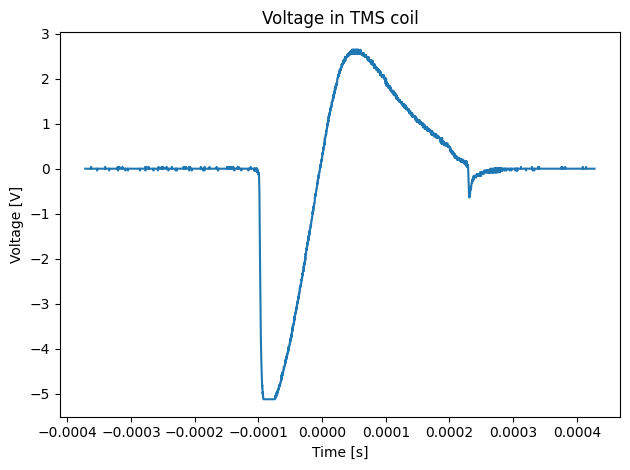

In [9]:
plt.figure()
plt.plot(data["Time [s]"], data["Voltage [V]"])
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Voltage in TMS coil")
plt.tight_layout()

plt.savefig(os.path.join(output_folder_dir, f"{file_name}_RxCoil_voltage.png"),
            dpi=300,              # high resolution
            bbox_inches='tight')  # removes extra white space
plt.show()
plt.close()